# Intrusion Detection System Using Machine Learning Algorithms

**Problem Statement:** The task is to build a network intrusion detector, a predictive model capable of distinguishing between bad connections, called intrusions or attacks, and good normal connections.

**Intrusion Detection System** is a software application that detects network intrusion using various machine learning algorithms. IDS monitors a network or system for malicious activity and protects a computer network from unauthorized access by users, including perhaps insiders. The intrusion detector learning task is to build a predictive model (i.e., a classifier) capable of distinguishing between 'bad connections' (intrusion/attacks) and 'good (normal) connections'. Attacks fall into four main categories:

* #DOS: denial-of-service, e.g. syn flood.
* #R2L: unauthorized access from a remote machine, e.g., guessing password.
* #U2R: unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow'' attacks.
* #probing: surveillance and other probing, e.g., port scanning.

Dataset Description: Data files:

* kddcup.names: A list of features.\
* kddcup.data_10_percent: A 10% subset of the dataset.\
* training_attack_types: A list of intrusion types.

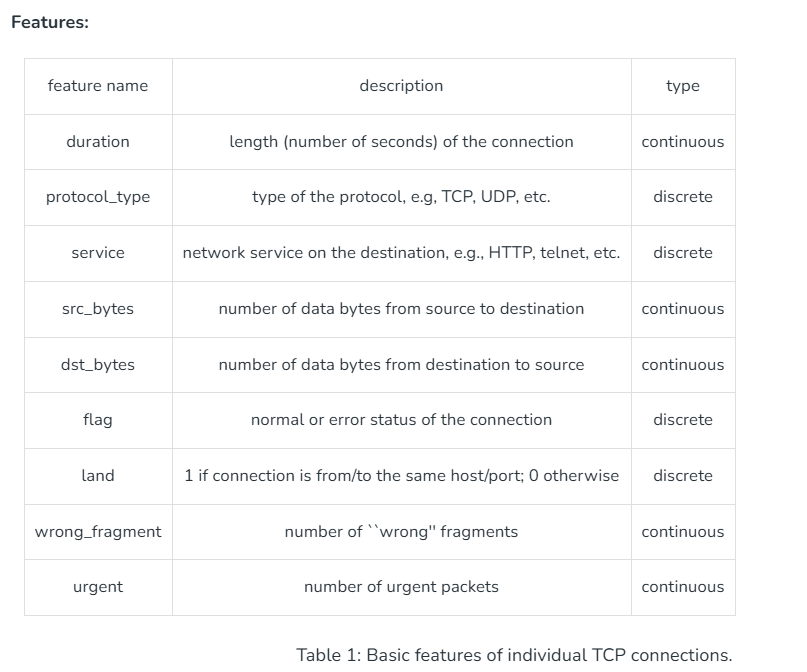

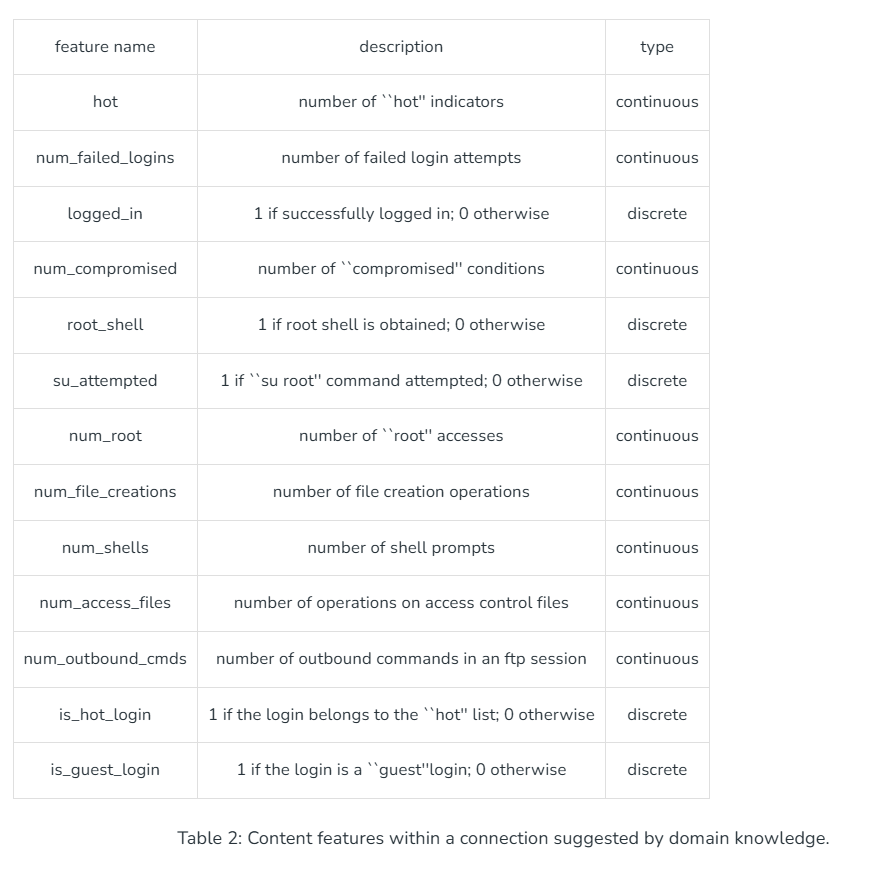

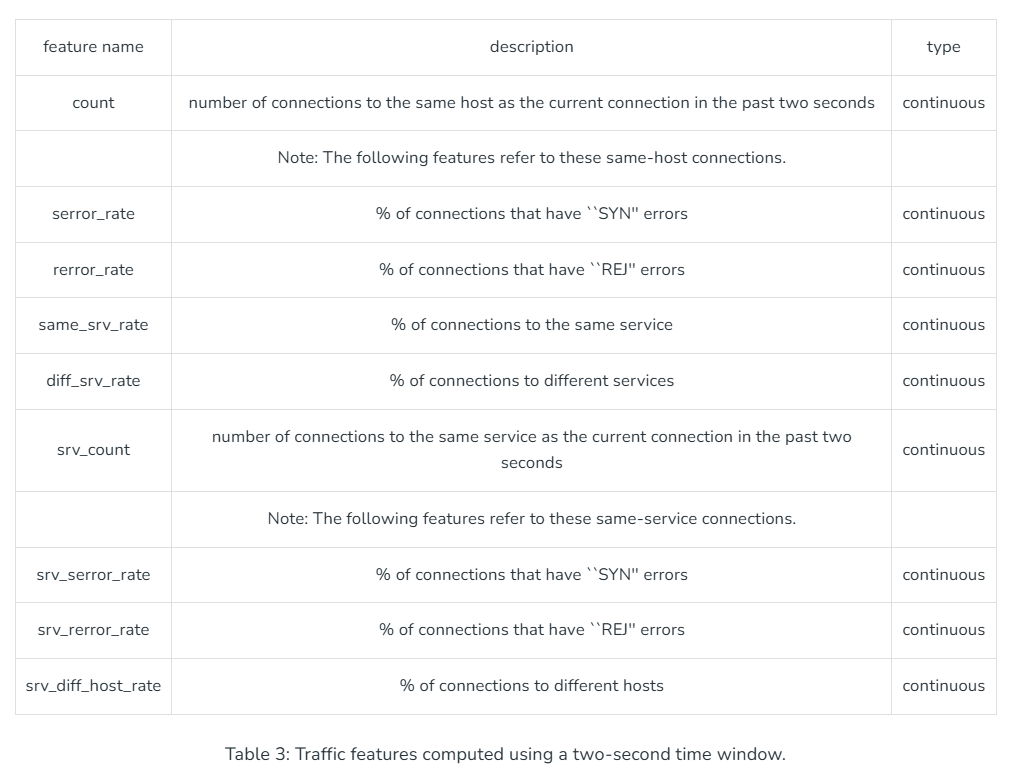

**Various Algorithms Applied:** Gaussian Naive Bayes, Decision Tree, Random Forest, Support Vector Machine, Logistic Regression.

**Approach Used:** I have applied various classification algorithms that are mentioned above on the KDD dataset and compare there results to build a predictive model.

## Step 1: Importing and Setting Up the Data
Code: Importing libraries and reading features list.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
with open("kddcup.names", 'r') as f:
    print(f.read())

back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,nmap,normal,perl,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster.
duration: continuous.
protocol_type: symbolic.
service: symbolic.
flag: symbolic.
src_bytes: continuous.
dst_bytes: continuous.
land: symbolic.
wrong_fragment: continuous.
urgent: continuous.
hot: continuous.
num_failed_logins: continuous.
logged_in: symbolic.
num_compromised: continuous.
root_shell: continuous.
su_attempted: continuous.
num_root: continuous.
num_file_creations: continuous.
num_shells: continuous.
num_access_files: continuous.
num_outbound_cmds: continuous.
is_host_login: symbolic.
is_guest_login: symbolic.
count: continuous.
srv_count: continuous.
serror_rate: continuous.
srv_serror_rate: continuous.
rerror_rate: continuous.
srv_rerror_rate: continuous.
same_srv_rate: continuous.
diff_srv_rate: continuous.
srv_diff_host_rate: continuous.
dst_host_count: continuous.
dst_host_srv_count: con

Appending columns to the dataset and adding a new column name 'target' to the dataset.

In [4]:
cols ="""duration,
protocol_type,
service,
flag,
src_bytes,
dst_bytes,
land,
wrong_fragment,
urgent,
hot,
num_failed_logins,
logged_in,
num_compromised,
root_shell,
su_attempted,
num_root,
num_file_creations,
num_shells,
num_access_files,
num_outbound_cmds,
is_host_login,
is_guest_login,
count,
srv_count,
serror_rate,
srv_serror_rate,
rerror_rate,
srv_rerror_rate,
same_srv_rate,
diff_srv_rate,
srv_diff_host_rate,
dst_host_count,
dst_host_srv_count,
dst_host_same_srv_rate,
dst_host_diff_srv_rate,
dst_host_same_src_port_rate,
dst_host_srv_diff_host_rate,
dst_host_serror_rate,
dst_host_srv_serror_rate,
dst_host_rerror_rate,
dst_host_srv_rerror_rate"""

columns =[]
for c in cols.split(',\n'):
    if(c.strip()):
       columns.append(c.strip())

columns.append('target')
print(len(columns))

42


Reading the 'attack_types' file.

In [5]:
with open("training_attack_types", 'r') as f:
    print(f.read())

back dos
buffer_overflow u2r
ftp_write r2l
guess_passwd r2l
imap r2l
ipsweep probe
land dos
loadmodule u2r
multihop r2l
neptune dos
nmap probe
perl u2r
phf r2l
pod dos
portsweep probe
rootkit u2r
satan probe
smurf dos
spy r2l
teardrop dos
warezclient r2l
warezmaster r2l




Creating a dictionary of attack_types

In [6]:
attacks_types = {
    'normal': 'normal',
'back': 'dos',
'buffer_overflow': 'u2r',
'ftp_write': 'r2l',
'guess_passwd': 'r2l',
'imap': 'r2l',
'ipsweep': 'probe',
'land': 'dos',
'loadmodule': 'u2r',
'multihop': 'r2l',
'neptune': 'dos',
'nmap': 'probe',
'perl': 'u2r',
'phf': 'r2l',
'pod': 'dos',
'portsweep': 'probe',
'rootkit': 'u2r',
'satan': 'probe',
'smurf': 'dos',
'spy': 'r2l',
'teardrop': 'dos',
'warezclient': 'r2l',
'warezmaster': 'r2l',
}

Reading the dataset('kddcup.data_10_percent_corrected") and adding Attack Type feature in the training dataset where attack type feature has 5 distinct values i.e. dos, normal, probe, r2l, u2r.

In [7]:
path = "kddcup.data_10_percent_corrected"
df = pd.read_csv(path, names = columns)

# Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r:attacks_types[r[:-1]])
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


Shape of dataframe and getting data type of each feature

In [8]:
df.shape

(494021, 43)

Finding missing values of all features.

In [9]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

No missing value found, so we can further proceed to our next step.

## Step 2: Data Exploration
Finding Categorical Features

In [10]:
# Finding categorical features
num_cols = df._get_numeric_data().columns

cate_cols = list(set(df.columns)-set(num_cols))
cate_cols.remove('target')
cate_cols.remove('Attack Type')

cate_cols

['flag', 'protocol_type', 'service']

Visualizing Categorical Features using bar graph

In [11]:
def bar_graph(feature):
    df[feature].value_counts().plot(kind="bar")

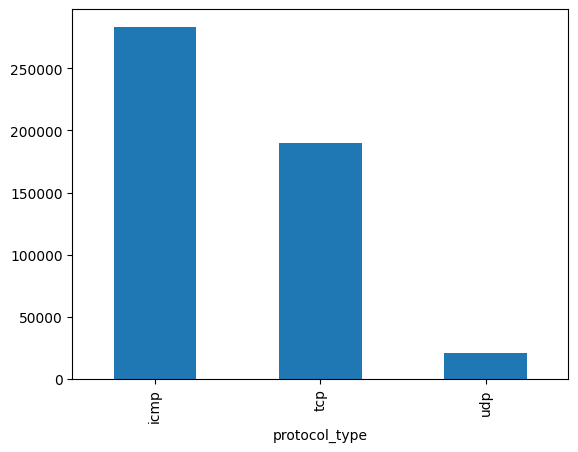

In [12]:
bar_graph('protocol_type')

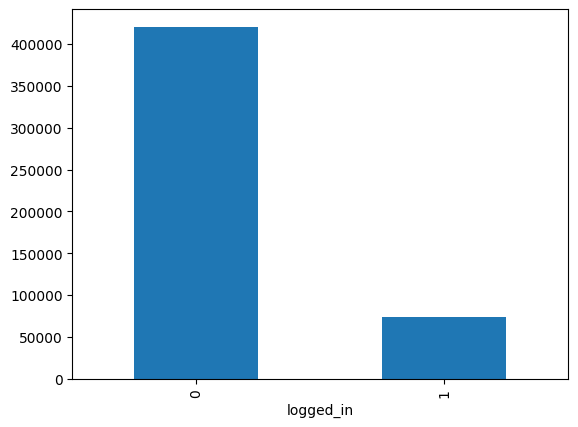

In [13]:
bar_graph('logged_in')

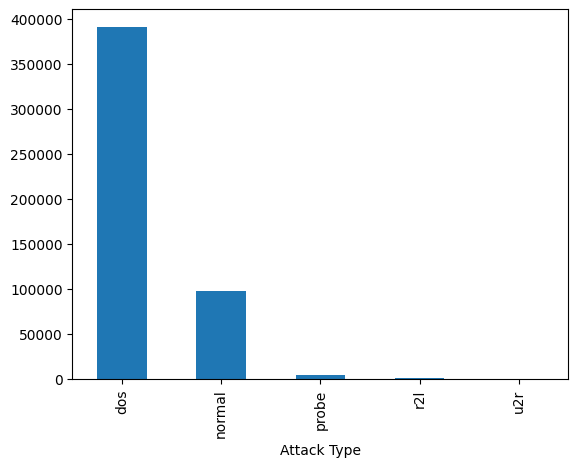

In [14]:
bar_graph('Attack Type')

## Step 3: Data Preprocessing

In [15]:
df = df.drop(['target'], axis=1)
df = df.dropna(axis='columns')

# Filter numeric columns
ndf = df[[col for col in df.columns if df[col].nunique() > 1 and pd.api.types.is_numeric_dtype(df[col])]]

# Prepare feature matrix (X) and target variable (y)
y = df[['Attack Type']]
X = df.drop(['Attack Type'], axis=1)

## Step 4: Splitting the Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Shape of X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}, y_test: {y_test.shape}")

Shape of X_train: (330994, 41), X_test: (163027, 41)
Shape of y_train: (330994, 1), y_test: (163027, 1)


## Step 5: Feature Encoding

In [17]:
# Map protocol_type to integers
pmap = {'icmp': 0, 'tcp': 1, 'udp': 2}
X_train['protocol_type'] = X_train['protocol_type'].map(pmap)
X_test['protocol_type'] = X_test['protocol_type'].map(pmap)

# Map flag to integers
fmap = {'SF': 0, 'S0': 1, 'REJ': 2, 'RSTR': 3, 'RSTO': 4, 'SH': 5, 'S1': 6, 'S2': 7, 'RSTOS0': 8, 'S3': 9, 'OTH': 10}
X_train['flag'] = X_train['flag'].map(fmap)
X_test['flag'] = X_test['flag'].map(fmap)

## Step 6: Correlation Analysis

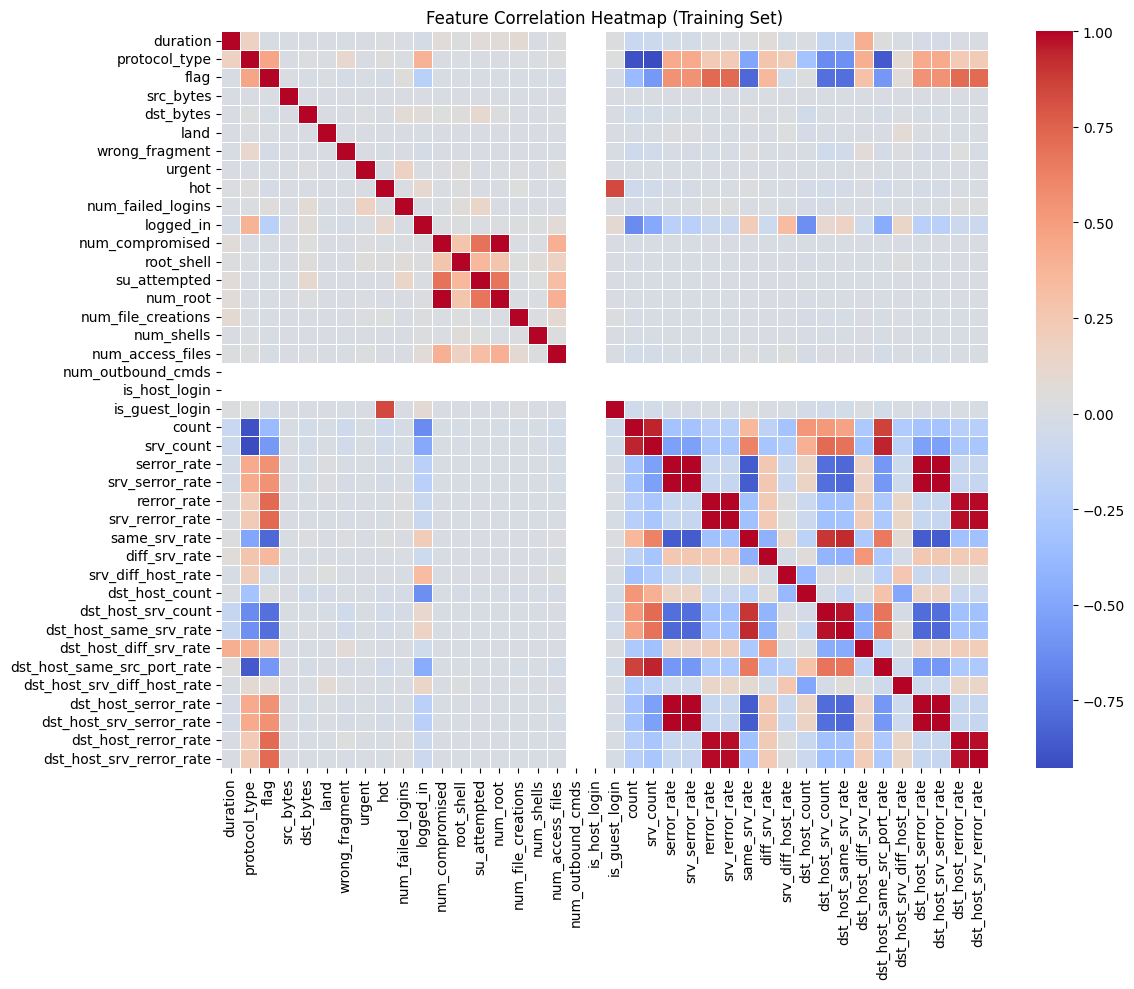

In [18]:
# Select numeric features for correlation matrix
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
corr = X_train_numeric.corr()

# Display heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

## Step 7: Removing Highly Correlated Features

In [19]:
highly_correlated = ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_srv_serror_rate',
                     'dst_host_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
                     'dst_host_same_srv_rate']
X_train.drop(columns=highly_correlated, axis=1, inplace=True)
X_test.drop(columns=highly_correlated, axis=1, inplace=True)

Dropping Columns that don't provide high value:

In [20]:
X_train.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)
X_test.drop(['is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)

X_train.drop('service', axis=1, inplace=True)
X_test.drop('service', axis=1, inplace=True)

Correlation Matrix with transformed dataset:

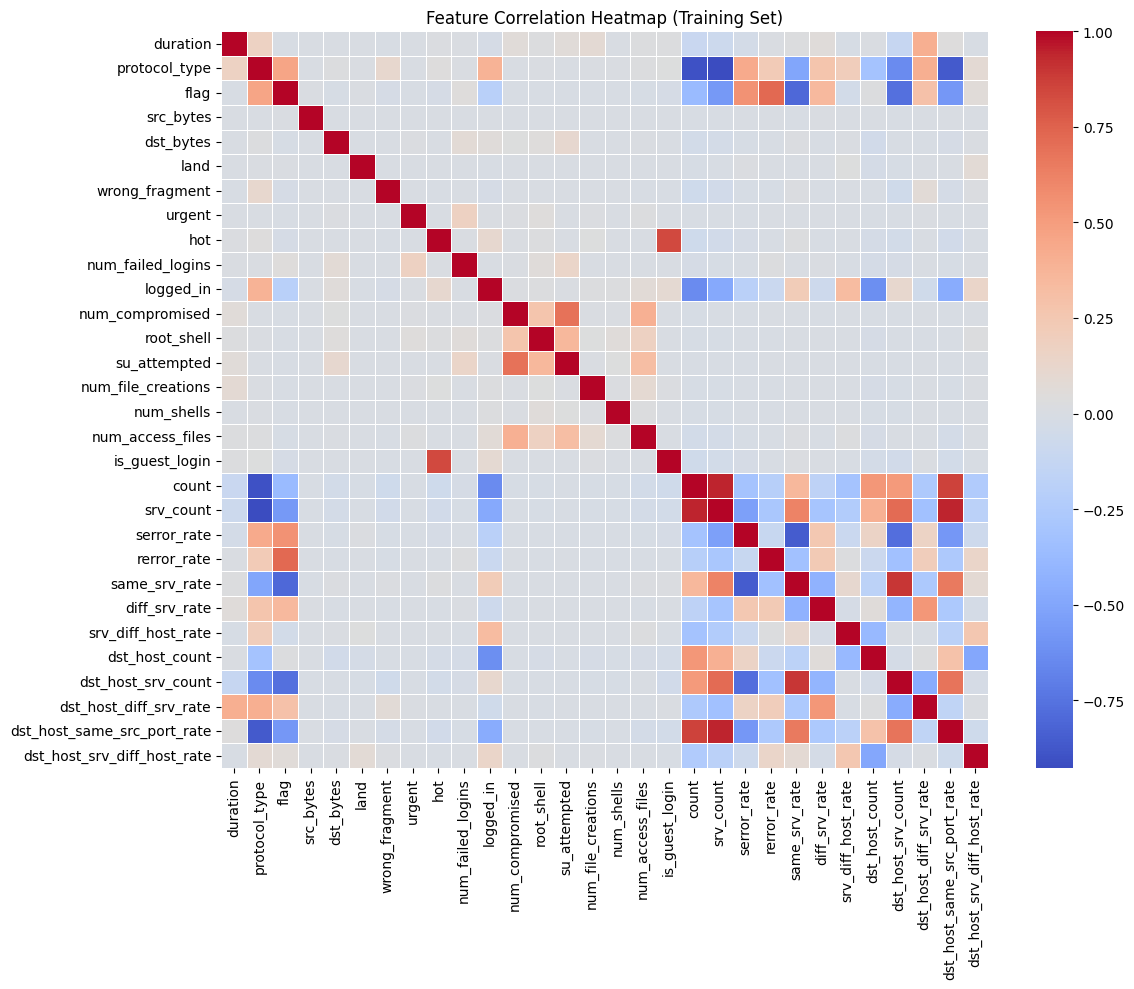

In [21]:
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])

corr = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Set)')
plt.tight_layout()
plt.show()

## Step 8: Scaling the Data

In [22]:
sc = MinMaxScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(f"Shape of X_train after scaling: {X_train.shape}")
print(f"Shape of X_test after scaling: {X_test.shape}")

Shape of X_train after scaling: (330994, 30)
Shape of X_test after scaling: (163027, 30)


## Step 9: Model Training and Test Accuracy

In [23]:
# Initialize classifiers
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=30),
    "SVM": SVC(gamma='scale'),
    "Logistic Regression": LogisticRegression(max_iter=1200000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
}

train_scores = []
test_scores = []
train_times = []
test_times = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train, y_train.values.ravel())
    end = time.time()
    train_time = end - start

    start = time.time()
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    end = time.time()
    test_time = end - start

    train_score = accuracy_score(y_train, y_pred_train) * 100
    test_score = accuracy_score(y_test, y_pred_test) * 100

    train_scores.append(train_score)
    test_scores.append(test_score)
    train_times.append(train_time)
    test_times.append(test_time)

    print(f"{name} - Train Accuracy: {train_score:.2f}%, Test Accuracy: {test_score:.2f}%")
    print(f"Training Time: {train_time:.4f}s, Testing Time: {test_time:.4f}s")


Training Naive Bayes...
Naive Bayes - Train Accuracy: 87.95%, Test Accuracy: 87.90%
Training Time: 1.0797s, Testing Time: 1.0814s

Training Decision Tree...
Decision Tree - Train Accuracy: 99.06%, Test Accuracy: 99.05%
Training Time: 2.0064s, Testing Time: 0.1259s

Training Random Forest...
Random Forest - Train Accuracy: 100.00%, Test Accuracy: 99.97%
Training Time: 12.0581s, Testing Time: 1.5511s

Training SVM...
SVM - Train Accuracy: 99.88%, Test Accuracy: 99.88%
Training Time: 212.3221s, Testing Time: 370.0851s

Training Logistic Regression...
Logistic Regression - Train Accuracy: 99.36%, Test Accuracy: 99.36%
Training Time: 9.9407s, Testing Time: 0.1419s

Training Gradient Boosting...
Gradient Boosting - Train Accuracy: 99.79%, Test Accuracy: 99.77%
Training Time: 350.8626s, Testing Time: 5.0588s


# Conclusion
## Naive Bayes:
Train Accuracy: 87.95%, Test Accuracy: 87.90%\
This model performs decently but is not as good as others. It's good for a quick baseline but not the best choice for this problem.
## Decision Tree:
Train Accuracy: 99.06%, Test Accuracy: 99.05%\
This model is very accurate and performs almost equally well on both the training and test data. It’s great but might overfit the data (get too specialized).
## Random Forest:
Train Accuracy: 100.00%, Test Accuracy: 99.97%\
This model does perfectly on the training data and performs very well on the test data too. It's a strong contender but could be overfitting the training data.
## SVM (Support Vector Machine):
Train Accuracy: 99.88%, Test Accuracy: 99.88%\
SVM also performs almost perfectly on both training and test data. However, it takes a long time to train, which can be a downside for larger datasets.
## Logistic Regression:
Train Accuracy: 99.36%, Test Accuracy: 99.36%\
This model is simple, efficient, and performs really well with high accuracy, making it a good choice if you need something fast and reliable.
## Gradient Boosting:
Train Accuracy: 99.79%, Test Accuracy: 99.77%\
This model is another high performer with excellent accuracy on both training and test data. The downside is it takes a long time to train.